In [31]:
import kagglehub
path = kagglehub.dataset_download("samithsachidanandan/human-face-emotions")

Using Colab cache for faster access to the 'human-face-emotions' dataset.


In [32]:
import os
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.utils.class_weight import compute_class_weight

In [33]:
base_path = path
image_root_dir = os.path.join(base_path, "Data") # Correct path to the root of image classes
print(f"Listing directories in {image_root_dir}:")
for expression in os.listdir(image_root_dir):
    class_path = os.path.join(image_root_dir, expression)
    if os.path.isdir(class_path): # Check if it's a directory (a class folder)
        num_images = len(os.listdir(class_path))
        print(f"{num_images} {expression} images")

Listing directories in /kaggle/input/human-face-emotions/Data:
9732 Fear images
8227 Suprise images
10148 Angry images
12553 Sad images
18439 Happy images


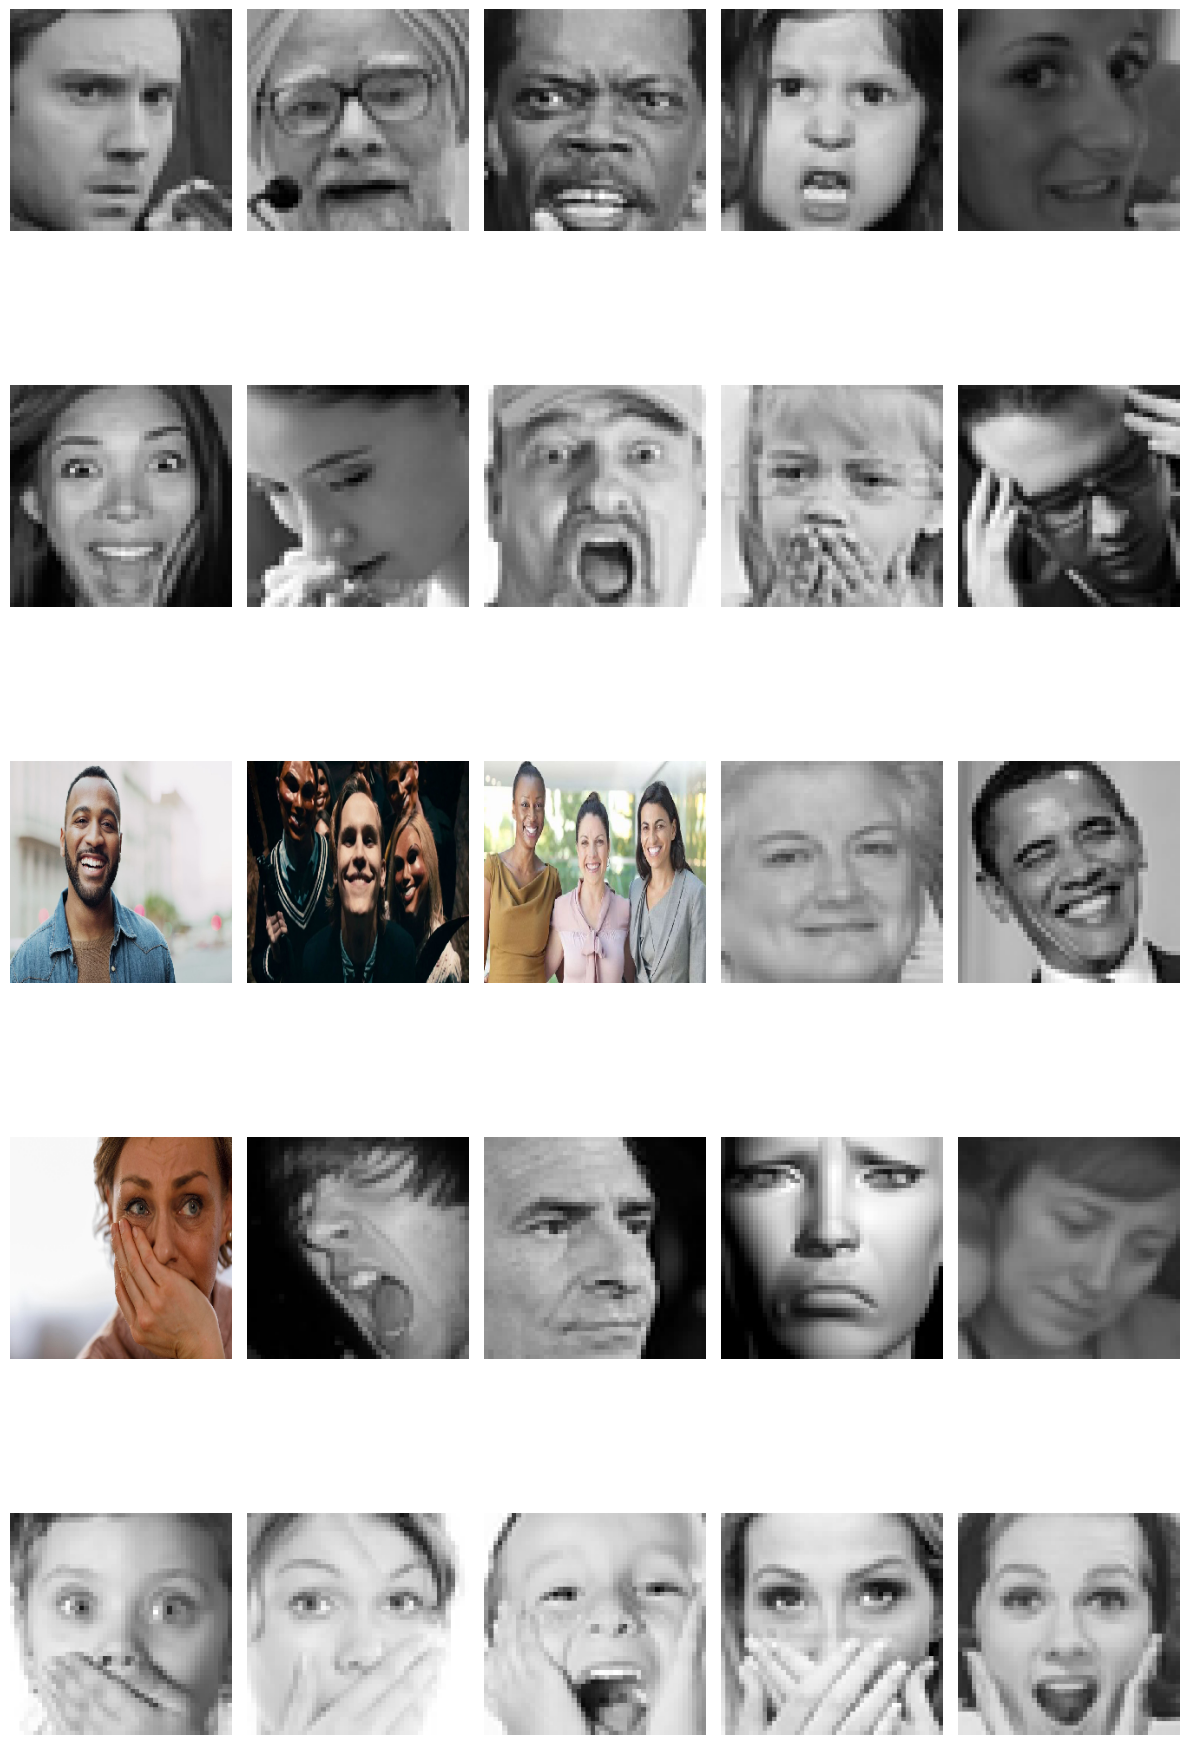

In [34]:
from tensorflow.keras.preprocessing.image import load_img

pic_size = 256

plt.figure(0, figsize=(12,20))
cpt = 0

image_root_dir = os.path.join(base_path, "Data") # This is the correct root for classes
classes = sorted([d for d in os.listdir(image_root_dir) if os.path.isdir(os.path.join(image_root_dir, d))]) # Get actual class directories
# show up to 5 images per class, safe against small folders
for expression in classes:
    expr_dir = os.path.join(image_root_dir, expression) # Path to class directory
    image_files = sorted(os.listdir(expr_dir))
    if not image_files:
        continue
    sample_files = image_files[:5]  # pick first up-to-5 images
    for filename in sample_files:
        cpt += 1
        plt.subplot(len(classes), 5, cpt)
        img_path = os.path.join(expr_dir, filename)
        img = load_img(img_path, target_size=(pic_size, pic_size))
        plt.imshow(img)
        plt.axis('off')

plt.tight_layout()
plt.show()

In [35]:
IMG_SIZE = 100
BATCH_SIZE = 512
EPOCHS = 40

DATA_DIR = os.path.join(path, "Data")

In [36]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,


    horizontal_flip=True
)

validation_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 47282 images belonging to 5 classes.
Found 11817 images belonging to 5 classes.


In [37]:
classes = train_generator.classes

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(weights))

print(class_weights)

{0: np.float64(1.164724719793078), 1: np.float64(1.2145389160030824), 2: np.float64(0.6410249457700651), 3: np.float64(0.9415911580205119), 4: np.float64(1.4367061683378912)}


In [38]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Fine-tune the top part only
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = base_model(inputs, training=False)

x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(
    512,
    activation="relu"
)(x)

x = Dropout(0.5)(x)

outputs = Dense(
    train_generator.num_classes,
    activation="softmax"
)(x)

model = Model(inputs, outputs)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,647,557 (94.02 MB)

 Trainable params: 15,505,925 (59.15 MB)

 Non-trainable params: 9,141,632 (34.87 MB)

In [39]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)

In [40]:
callbacks = [

    ModelCheckpoint(
        "best_resnet50.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    EarlyStopping(
        monitor="val_accuracy",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_accuracy",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

In [41]:
history = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=EPOCHS,

    class_weight=class_weights,

    callbacks=callbacks
)

Epoch 1/40
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5042 - loss: 1.5783
Epoch 1: val_accuracy improved from None to 0.17356, saving model to best_resnet50.keras

Epoch 1: finished saving model to best_resnet50.keras
93/93 ━━━━━━━━━━━━━━━━━━━━ 302s 3s/step - accuracy: 0.5762 - loss: 1.3215 - val_accuracy: 0.1736 - val_loss: 68.0221 - learning_rate: 0.0010
Epoch 2/40
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6841 - loss: 0.9258
Epoch 2: val_accuracy improved from 0.17356 to 0.68122, saving model to best_resnet50.keras

Epoch 2: finished saving model to best_resnet50.keras
93/93 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.6933 - loss: 0.8800 - val_accuracy: 0.6812 - val_loss: 0.8788 - learning_rate: 0.0010
Epoch 3/40
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7639 - loss: 0.6470
Epoch 3: val_accuracy improved from 0.68122 to 0.72556, saving model to best_resnet50.keras

Epoch 3: finished saving model to best_resnet50.keras
93/93 ━━━━━━━━━━━━━━━━━━━━ 144s 

In [42]:
model.save("emotion_resnet50.keras")

In [43]:

model_json = model.to_json()

with open("model.json", "w") as json_file:
    json_file.write(model_json)

print("Model saved successfully")

Model saved successfully


In [44]:
validation_generator.reset()

predictions = model.predict(
    validation_generator,
    verbose=1
)

y_pred = np.argmax(
    predictions,
    axis=1
)

y_true = validation_generator.classes

24/24 ━━━━━━━━━━━━━━━━━━━━ 23s 747ms/step


In [45]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=list(
            validation_generator.class_indices.keys()
        )
    )
)

print(
    "Accuracy:",
    accuracy_score(
        y_true,
        y_pred
    )
)

print(
    "Precision:",
    precision_score(
        y_true,
        y_pred,
        average="weighted"
    )
)

print(
    "Recall:",
    recall_score(
        y_true,
        y_pred,
        average="weighted"
    )
)

print(
    "F1:",
    f1_score(
        y_true,
        y_pred,
        average="weighted"
    )
)

              precision    recall  f1-score   support

       Angry       0.95      0.93      0.94      2029
        Fear       0.94      0.91      0.92      1946
       Happy       0.98      0.98      0.98      3687
         Sad       0.93      0.95      0.94      2510
     Suprise       0.96      0.98      0.97      1645

    accuracy                           0.95     11817
   macro avg       0.95      0.95      0.95     11817
weighted avg       0.95      0.95      0.95     11817

Accuracy: 0.954049251078954
Precision: 0.9540829781023609
Recall: 0.954049251078954
F1: 0.9539562864647593


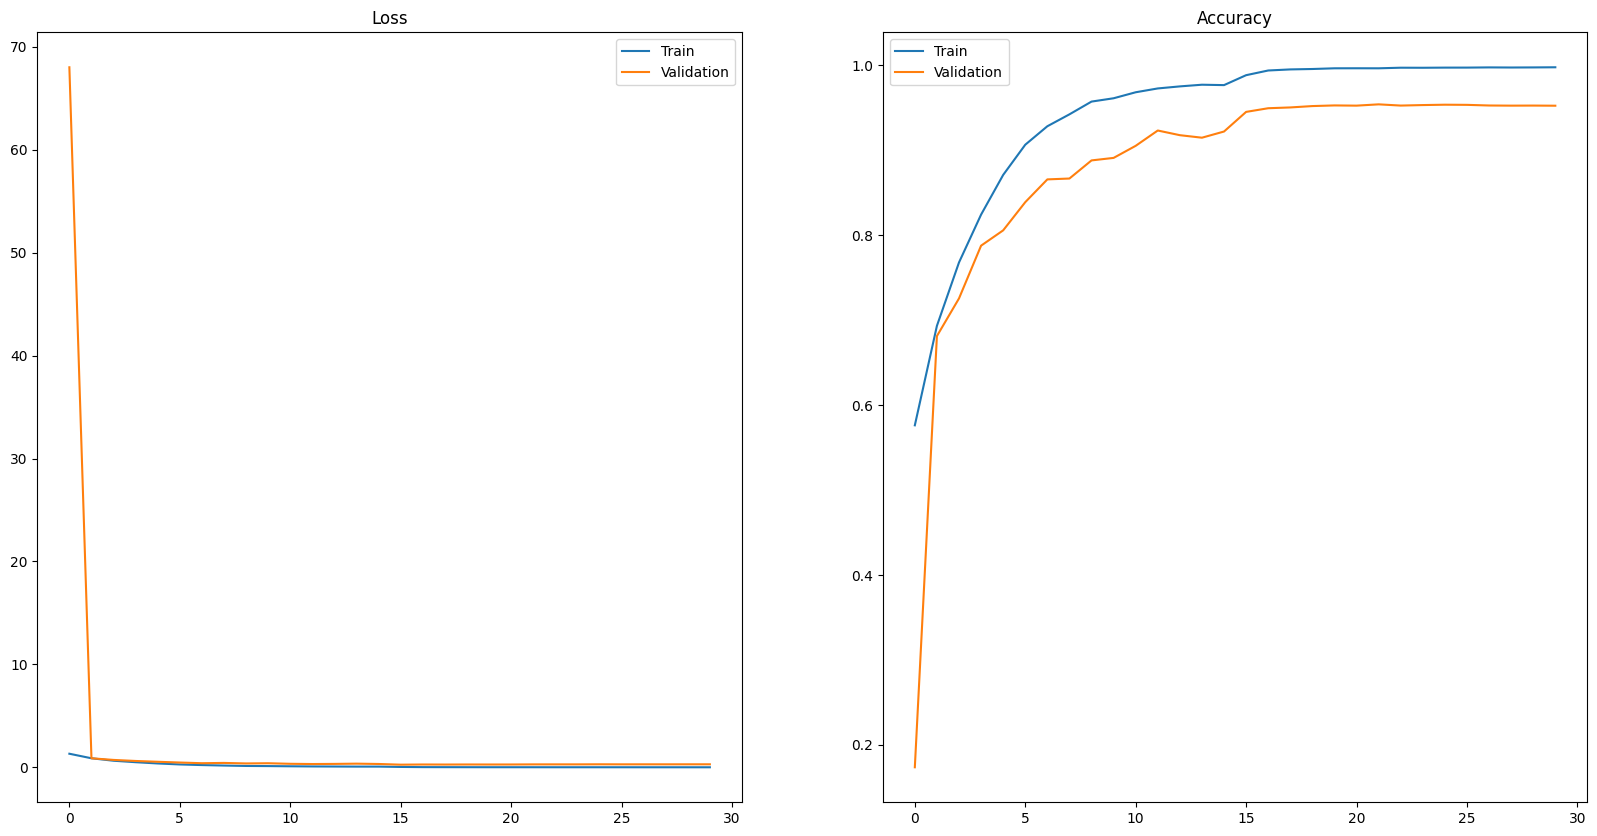

In [46]:
plt.figure(figsize=(20,10))

plt.subplot(1,2,1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 586ms/step
Accuracy: 0.954049251078954
Precision: 0.9540829781023609
Recall: 0.954049251078954
F1 Score: 0.9539562864647593

Classification Report:

              precision    recall  f1-score   support

       Angry       0.95      0.93      0.94      2029
        Fear       0.94      0.91      0.92      1946
       Happy       0.98      0.98      0.98      3687
         Sad       0.93      0.95      0.94      2510
     Suprise       0.96      0.98      0.97      1645

    accuracy                           0.95     11817
   macro avg       0.95      0.95      0.95     11817
weighted avg       0.95      0.95      0.95     11817



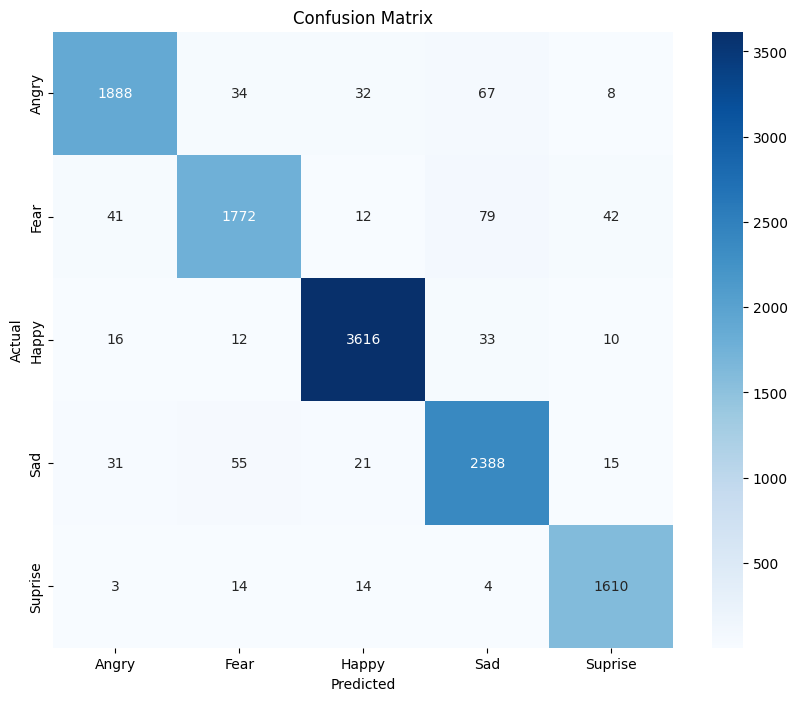

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

predictions = model.predict(validation_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = validation_generator.classes

class_names = list(validation_generator.class_indices.keys())

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average='weighted'))
print("Recall:", recall_score(y_true, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_true, y_pred, average='weighted'))

print("\nClassification Report:\n")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()